In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = '1505_knight'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e4)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.0001, # = 
    'c_rate': 5,
    'u_per': 30,
    }


VARIABLES = ['R0', 'R1', 'C1','k']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


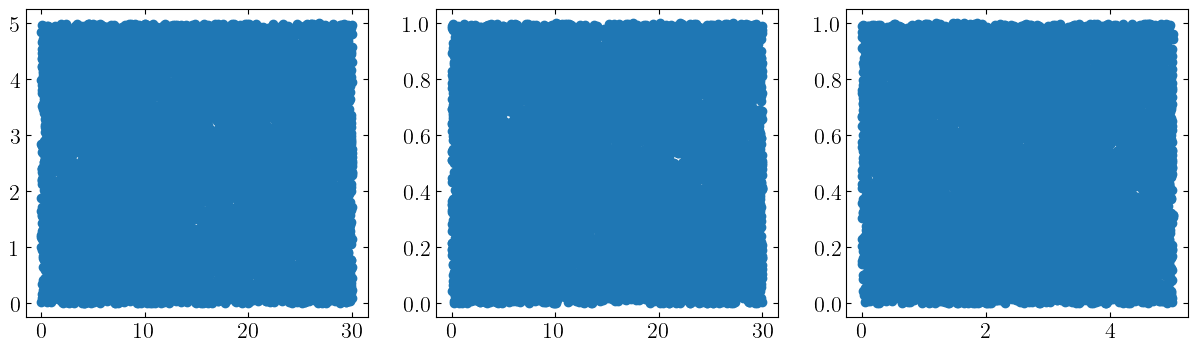

In [3]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('lhs_samples_2.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('combo_half.txt', delimiter=';')
#s_data = s_data[s_data['u_par', 'C', 'soc'].isin(df.values.tolist())]
f, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[2].plot(df['C_rate'],df['SOC'], 'o')

#display(df)
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)


In [4]:

s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)
s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']]
s_data['C'] = s_data['I'].copy() * 3600/Q0 
REF_VALUES['s'] = np.max(s_data['s'].values)
s_data['s'] = s_data['s'].copy() / REF_VALUES['s']
s_data['C'] = s_data['C'].copy() / REF_VALUES['c_rate']
s_data['u_per'] = s_data['u_per'].copy() / REF_VALUES['u_per']

s_data['sdot'] = s_data['sdot'].copy() / REF_VALUES['sdot']
print(REF_VALUES['s'])

s_data.describe()

0.37266314


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_4104/1631384710.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data['C'] = s_data['I'].copy() * 3600/Q0
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_4104/1631384710.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data['s'] = s_data['s'].copy() / REF_VALUES['s']
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_4104/1631384710.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.432018,1.389439,0.279603
std,6.807070,0.309418,0.257924,0.250823,1.345169,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.027937,0.000000
25%,0.000000,0.176667,0.329973,0.221596,0.039598,0.000000
50%,4.480394,0.406667,0.548750,0.426062,0.941159,0.180000
75%,10.952074,0.686667,0.762836,0.637857,2.198551,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.410481,1.000000


In [5]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


In [6]:
samples = generate_data(df.values)

100%|██████████| 10000/10000 [00:08<00:00, 1195.42it/s]


In [7]:
# s_list = []; ds_list = []
# for i,tr in enumerate(trajs):
#     s, ds = _compute_element('s', tr['I_seq']*3600 / Q0, tr['u_per'], tr['soc'], source='nn')
#     s_list.append(s)
#     ds_list.append(ds)
#     print(f"traj {i} done")


In [8]:
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['u_per']
data['C'] =  data['C'] / REF_VALUES['c_rate']

data.describe() 

,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.798570,3.970051,6.199307,2.802108,0.499987,0.499977,0.499957
std,0.258918,6.657264,4.605508,0.342034,0.288700,0.288720,0.288703
min,0.700000,0.473039,0.525449,2.272266,0.000000,0.000000,0.000000
25%,0.700000,0.662761,1.850634,2.496637,0.249950,0.250008,0.250000
50%,0.700000,0.843171,5.180920,2.759576,0.500000,0.500017,0.500000
75%,0.700000,1.711790,10.306328,3.078555,0.750000,0.749958,0.750000
max,1.500000,19.271268,16.348788,3.543507,1.000000,0.999900,1.000000


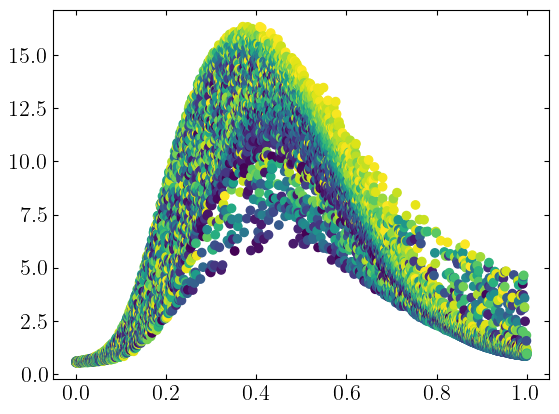

In [9]:
# plotting
arg_soc_sort = np.argsort(df_samples['soc'])
soc_sort = df_samples['soc'].values[arg_soc_sort]
R0_sort = df_samples['R0'].values[arg_soc_sort]
R1_sort = df_samples['R1'].values[arg_soc_sort]
C1_sort = df_samples['C1'].values[arg_soc_sort]
k_sort = df_samples['k'].values[arg_soc_sort]

#plt.plot(soc_sort, R0_sort, '-', label='R0')
#plt.plot(soc_sort, R1_sort, '-', label='R1')
plt.scatter(soc_sort, C1_sort, c = df_samples['u_per'].values[arg_soc_sort], label='C1')
#plt.plot(soc_sort, k_sort, '-', label='k')

# Importing data

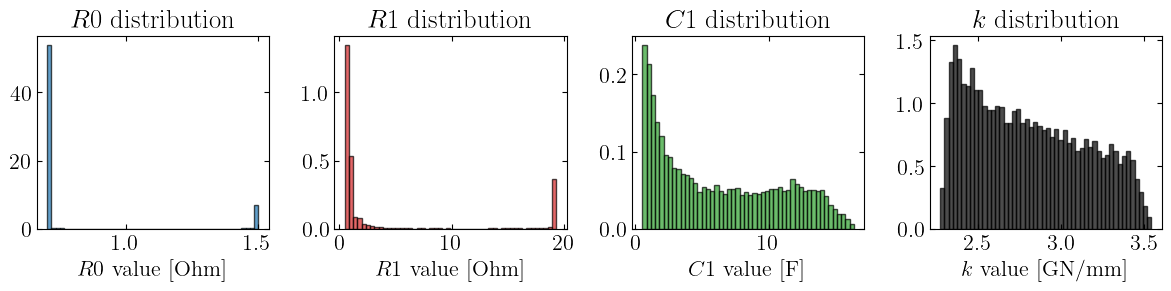

In [10]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

# f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

# for i, var in enumerate(VARIABLES):
#     ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
#     ax[i].set_title(f'${var}$ distribution')
#     ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
# plt.tight_layout()
# plt.show()

In [11]:
def get_XY(d_frame, s_frame = None):

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values #/ REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values #/ REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values #/ REF_VALUES['C1']
    Y_k  = d_frame['k'].values  #/ REF_VALUES['k']
    try:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

In [12]:
split_train = int(len(data) * 0.8)
s_split_train = int(len(s_data) * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:
    data_train  = data[:split_train]
    data_test   = data[split_train:]
    s_data_train = s_data[:s_split_train]
    s_data_test = s_data[s_split_train:]
X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_1405_knight...
Settings: iterations=2, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.06648722
Equation: 0.7971323

Model 1: Complexity=3, Loss=0.04556019
Equation: 0.5889798 ^ soc

Model 2: Complexity=5, Loss=0.03037243
Equation: (0.0039873663 ^ soc) + 0.5856868

Model 3: Complexity=8, Loss=0.02957418
Equation: exp(0.09017657 - (soc ^ C)) + 0.24818315

Model 4: Complexity=10, Loss=0.028310055
Equation: exp((0.09172542 - (soc ^ C)) + 0.13709617) + 0.14109792

Model 5: Complexity=16, Loss=0.027593266
Equation: square(square(sqrt(((((soc * 0.51057506) ^ 0.5457948) - -0.00012395158) ^ soc) ^ 1.2363913) - -0.11261457))

Model 6: Complexity=25, Loss=0.026709009
Equation: square(log(exp(0.09172542 - (((C * soc) - C) + (0.09172542 - ((soc * ((C * soc) - C)) + 0.13709617)))))) + 0.66262424

Model 7: Complexity=27, Loss=0.01976178
Equation: square(log(exp(0.12995288 - ((((C + 0.5906607) * soc) - C) - ((((soc * (C * soc)) - C) * soc) + 0.17531078))))) + 0.66530454



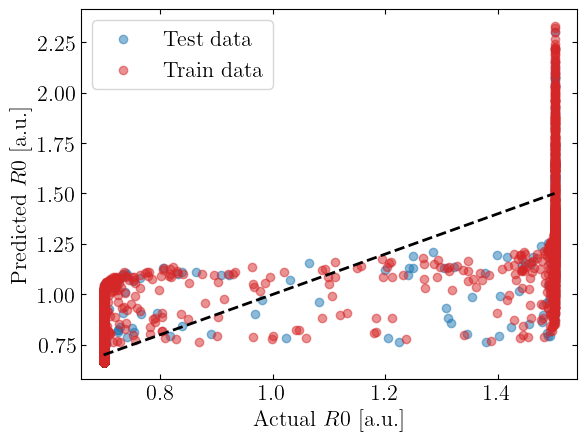

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: log(1.35698273791264*exp(C - soc*(C + 0.5906607) + soc*(C*soc**2 - C)))**2 + 0.66530454
Loss: 0.01976178
Best model complexity: 27


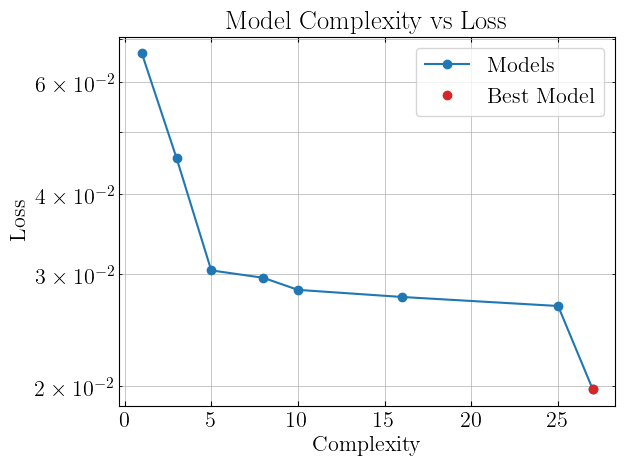

In [13]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_1405_knight...
Settings: iterations=2, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=43.976784
Equation: 3.9238896

Model 1: Complexity=3, Loss=41.98313
Equation: square(exp(C))

Model 2: Complexity=4, Loss=28.021835
Equation: cube(2.1098998 - soc)

Model 3: Complexity=5, Loss=16.286085
Equation: square(cube(1.6256021 - soc))

Model 4: Complexity=6, Loss=16.128374
Equation: cube(-1.1072531 / (-0.38808328 - soc))

Model 5: Complexity=9, Loss=10.476805
Equation: sqrt(square(cube(exp((C ^ soc) - soc))))

Model 6: Complexity=20, Loss=10.376203
Equation: exp((((C + (0.43755132 ^ soc)) - ((soc + -0.43648338) * 2.124829)) - soc) + 0.563994) - (1.8330522 - C)

Model 7: Complexity=22, Loss=10.038807
Equation: square((((((sqrt(sqrt(C)) + 0.22102435) - soc) - ((soc * 1.993018) - 1.3015403)) * 1.987349) + C) + -0.90622467) - soc

Model 8: Complexity=24, Loss=8.203897
Equation: exp(((square(square(square((C ^ soc) ^ soc))) + 0.6909204) * ((sqrt(C) - (soc - 1.2631203)) - soc)) + -0.30233967) - 1.1089717

Model 9: Complexity=25, Loss=8.023445
Equation: exp

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -C**2 - C + exp(((C**soc)**(8*soc) + 0.8103427)*(-(-0.3158281)*C - soc + 3.643332) - 3.8523784)
Loss: 7.1365047
Best model complexity: 26


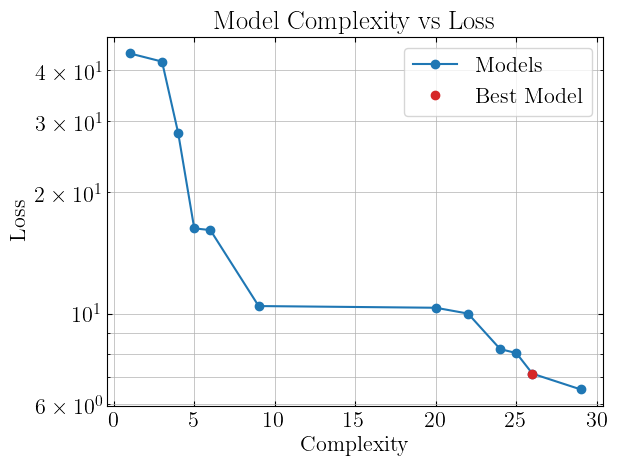

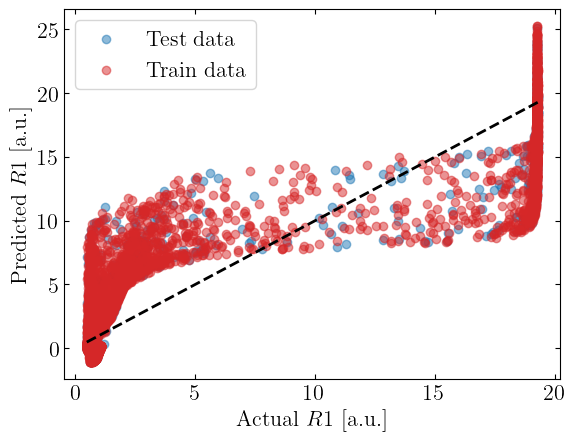

In [14]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_1405_knight...
Settings: iterations=2, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=21.240818
Equation: 6.2195334

Model 1: Complexity=3, Loss=20.918762
Equation: 6.649848 - soc

Model 2: Complexity=4, Loss=20.347576
Equation: 6.565449 - square(soc)

Model 3: Complexity=6, Loss=19.989668
Equation: 6.0538144 - (cube(soc) - d)

Model 4: Complexity=8, Loss=19.084105
Equation: square((1.271462 - (soc * soc)) + 1.4671192)

Model 5: Complexity=9, Loss=18.314262
Equation: exp(cube(1.1021745 * 1.1021745) - square(cube(soc)))

Model 6: Complexity=10, Loss=17.39073
Equation: square(2.6278067 - ((soc * (soc * soc)) * soc))

Model 7: Complexity=11, Loss=15.759311
Equation: exp(cube(1.0756907 - square(cube(soc))) + 0.9357993) - 0.80020297

Model 8: Complexity=12, Loss=12.534513
Equation: (cube(2.7068899 - square(cube(soc))) + -14.9862175) - (soc * -9.075348)

Model 9: Complexity=29, Loss=6.186938
Equation: (((5.0807886 - soc) + 1.2829196) + ((soc + -0.31712836) + ((soc + 2.1890028) + ((soc - square((soc + -3.0320323) + (soc * 5.9306326))) + soc)))) + sq

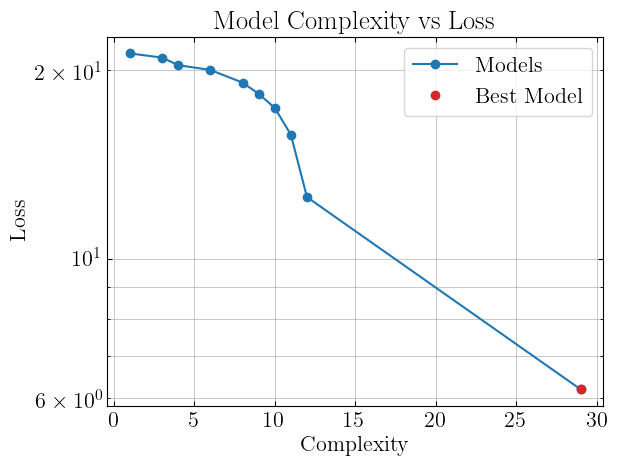

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(soc) + 3*soc - (6.9306326*soc - 3.0320323)**2 + 8.23558264
Loss: 6.186938
Best model complexity: 29


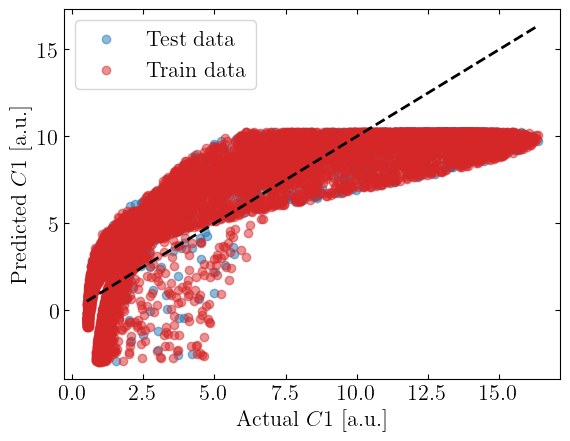

In [15]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_1405_knight...
Settings: iterations=2, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.11756006
Equation: 2.8033588

Model 1: Complexity=3, Loss=0.0053809034
Equation: d + 2.3024318

Model 2: Complexity=4, Loss=0.0052246447
Equation: square(d) + 2.4509244

Model 3: Complexity=5, Loss=0.0029158038
Equation: (d - -1.8876415) * 1.1734879

Model 4: Complexity=6, Loss=0.0013231318
Equation: exp(d / 1.2751724) + 1.2843014

Model 5: Complexity=13, Loss=0.0013147375
Equation: sqrt(((d + (cube(d + 0.8489529) - 2.3248775)) + 6.94889) - -0.060702287)

Model 6: Complexity=15, Loss=0.00051892875
Equation: sqrt(exp((1.4050122 - (sqrt(log(exp(soc))) * 0.07343295)) + d) + 1.2789817)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(4.07557646299707*exp(d - 0.07343295*sqrt(log(exp(soc)))) + 1.2789817)
Loss: 0.00051892875
Best model complexity: 15


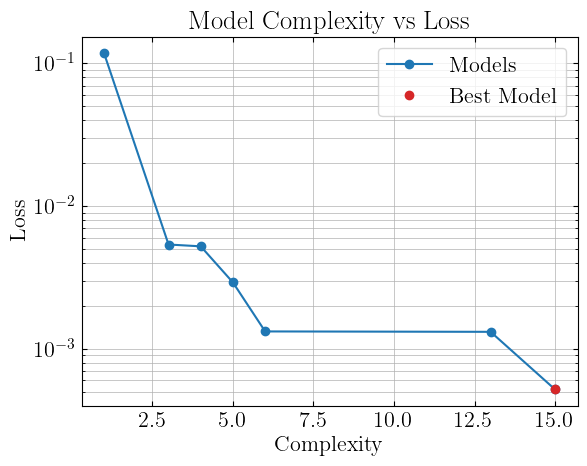

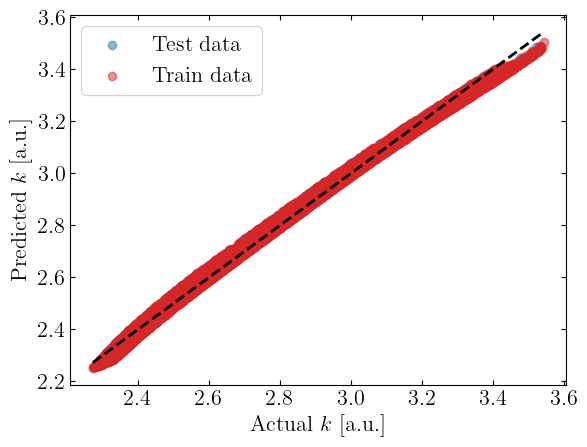

In [16]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

Variable names for element s: ['C', 'd', 'soc', 's']
Running symbolic regression for element s with run_id s_1505_knight...
Settings: iterations=15000, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.4105371
Equation: 1.0389093

Model 1: Complexity=2, Loss=0.7305976
Equation: exp(C)

Model 2: Complexity=3, Loss=0.0075597903
Equation: C / 0.20289676

Model 3: Complexity=5, Loss=0.002721481
Equation: (5.373371 - d) * C

Model 4: Complexity=7, Loss=0.0013378029
Equation: (5.179359 - (d * soc)) * C

Model 5: Complexity=8, Loss=0.00091962906
Equation: C * (5.252544 - (d * sqrt(soc)))

Model 6: Complexity=10, Loss=0.0007794726
Equation: (-0.0031787457 - C) * ((d * sqrt(soc)) + -5.2206)

Model 7: Complexity=12, Loss=0.0004575265
Equation: sqrt(square((C * ((sqrt(soc) * d) + -5.3106694)) - -0.028402217))

Model 8: Complexity=13, Loss=0.0003744138
Equation: (-0.007187331 - (C ^ 1.0304904)) * ((d * sqrt(soc)) + -5.260529)

Model 9: Complexity=14, Loss=0.00036152863
Equation: sqrt(square((C * (sqrt(sqrt(cube(d)) * soc) + -5.35423)) - -0.028374575))

Model 10: Complexity=15, Loss=0.0002873206
Equation: (-0.007139539 - (C ^ 1.0301224)) * (sqrt(cube(sqrt(d)) * soc) 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (C/(-(-0.028914386)*d*exp((soc - 1*0.4308119)/exp(C)) + soc*0.0104366895 + 0.19265772))**1.0281351 - 1*(-0.03537428)
Loss: 0.0001394175
Best model complexity: 24


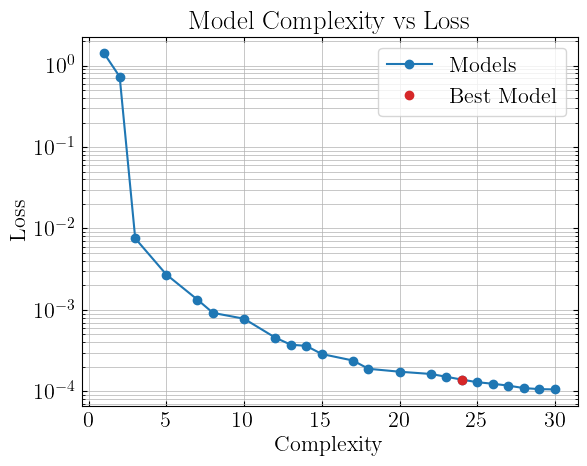

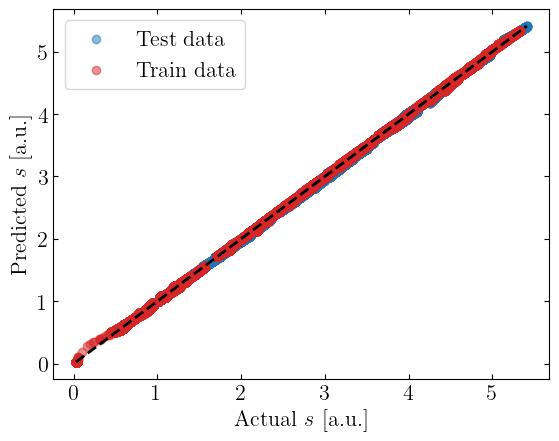

In [13]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION, elem = 's')
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s, s = True)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [ ]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [ ]:
# def plot_soc(models, df_samples):
#     C_fixed = df_samples['C'].iloc
#     u_per_fixed = traj['u_per']
#     soc = traj['soc'].values

#     f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

#     for var in VARIABLES:
#         model = models[var]
#         if var == 's':
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
#             Y_true = traj['sdot']
#         else:
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
#             Y_true = traj[var]
#         Y_plot = model.predict(X_plot) * REF_VALUES[var]
#         ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
#         ax[VARIABLES.index(var)].set_xlabel('SOC')
#         ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
#         ax[VARIABLES.index(var)].legend()
#         ax[VARIABLES.index(var)].invert_xaxis()
#     plt.tight_layout()



# traj = get_traj(trajectory_id = 1, test = True)
# plot_soc(MODEL_DICT, traj)

NameError: name 'get_traj' is not defined

In [20]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [14]:
if SAVE:
    #Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    #Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    #Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    #Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    #Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    #Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    #Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')